FIRST 5 RECORDS
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

DATASET SHAPE
(1000, 9)

COLUMN NAMES
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

DATA TYPES
Transaction ID       int64
Date                object
Cus

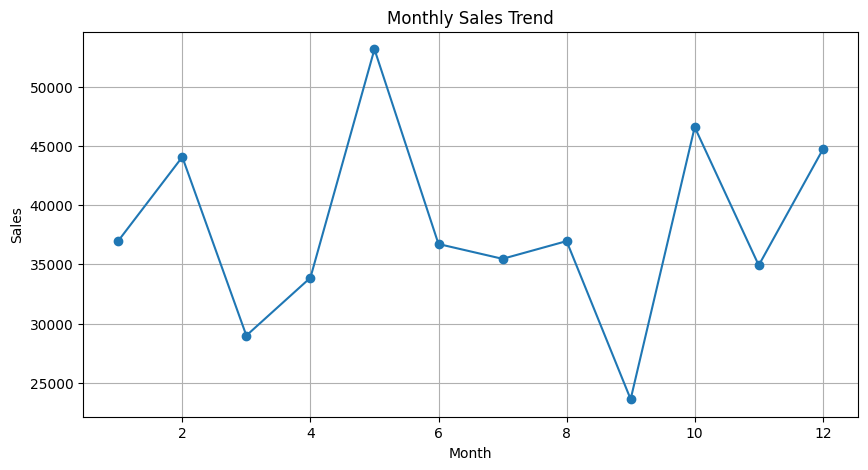

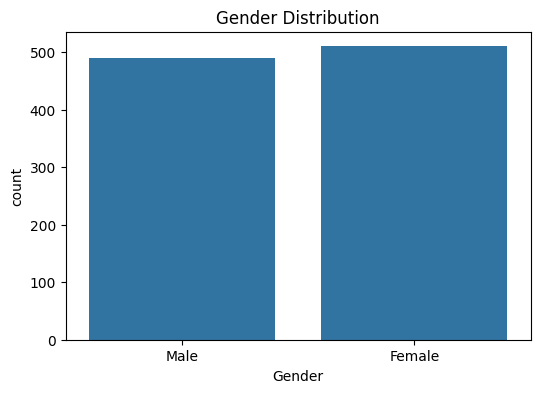

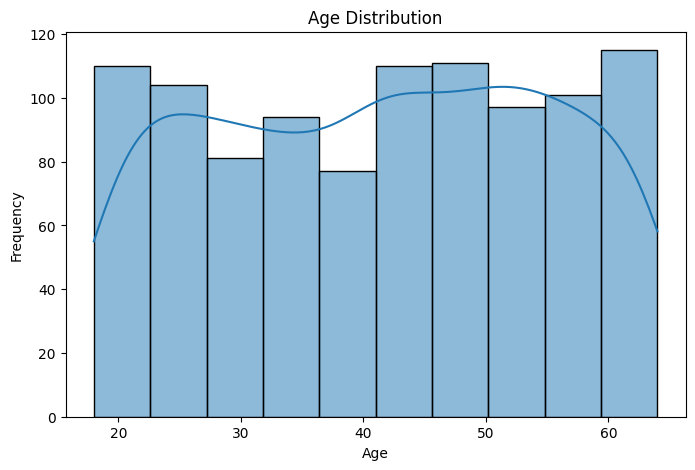

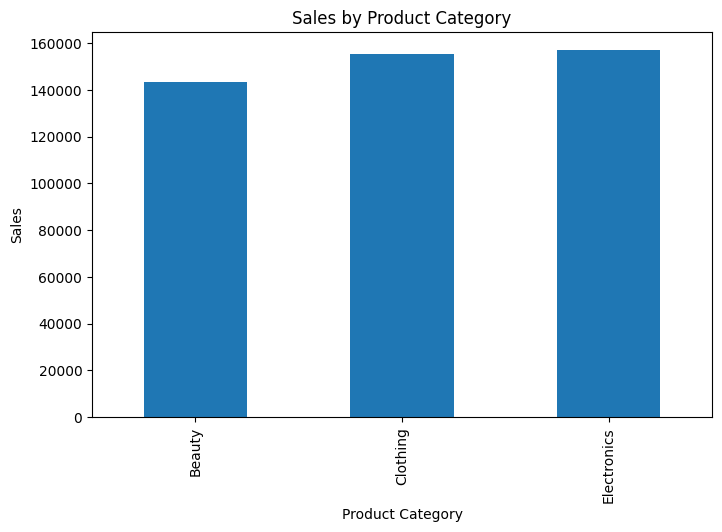


CATEGORY WISE SALES
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


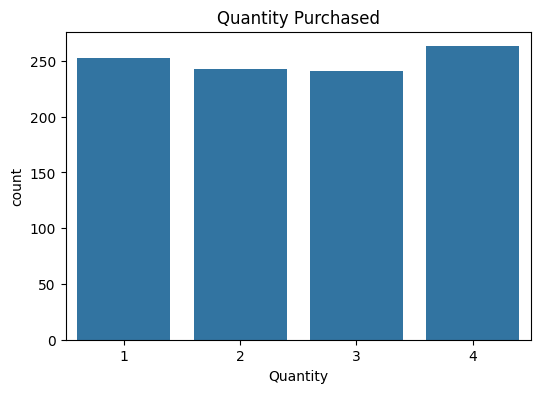


TOP 10 SALES
    Customer ID Product Category  Quantity  Total Amount
14      CUST015      Electronics         4          2000
64      CUST065      Electronics         4          2000
71      CUST072      Electronics         4          2000
73      CUST074           Beauty         4          2000
88      CUST089      Electronics         4          2000
92      CUST093           Beauty         4          2000
108     CUST109      Electronics         4          2000
117     CUST118      Electronics         4          2000
123     CUST124         Clothing         4          2000
138     CUST139           Beauty         4          2000


C:\Users\Keerthika\AppData\Local\Temp\ipykernel_15276\185018617.py:141: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df.groupby('Age Group')['Total Amount'].sum()


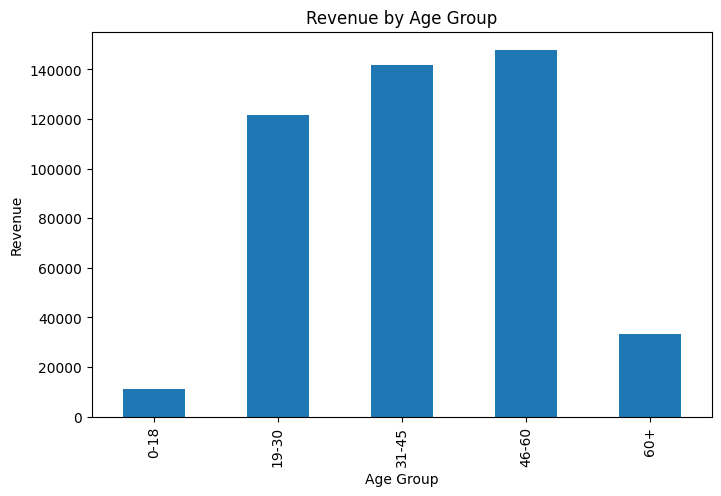

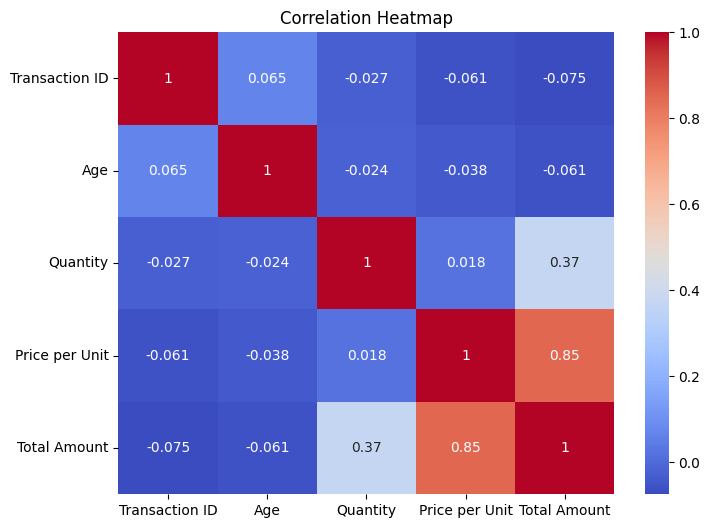


HIGHEST SELLING CATEGORY
Electronics
Sales: 156905

CUSTOMERS BY GENDER
Gender
Female    510
Male      490
Name: count, dtype: int64

MOST PURCHASED QUANTITY
4

========== PROJECT SUMMARY ==========
Total Revenue : 456000
Top Category : Electronics
Average Sales : 456.0
Maximum Sale : 2000
Minimum Sale : 25

EDA Completed Successfully!


In [5]:
# ==========================================
# RETAIL SALES DATA - EXPLORATORY DATA ANALYSIS
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("retail_sales_dataset.csv")

# ------------------------------------------
# Display Dataset
# ------------------------------------------
print("FIRST 5 RECORDS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

# ------------------------------------------
# Missing Values
# ------------------------------------------
print("\nMISSING VALUES")
print(df.isnull().sum())

# Remove Duplicates
df.drop_duplicates(inplace=True)

# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])

# ------------------------------------------
# Descriptive Statistics
# ------------------------------------------
print("\nDESCRIPTIVE STATISTICS")
print(df.describe())

print("\nMEAN OF TOTAL AMOUNT")
print(df['Total Amount'].mean())

print("\nMEDIAN OF TOTAL AMOUNT")
print(df['Total Amount'].median())

print("\nMODE OF TOTAL AMOUNT")
print(df['Total Amount'].mode()[0])

print("\nSTANDARD DEVIATION OF TOTAL AMOUNT")
print(df['Total Amount'].std())

# ------------------------------------------
# Total Revenue
# ------------------------------------------
total_revenue = df['Total Amount'].sum()

print("\nTOTAL REVENUE")
print(total_revenue)

# ------------------------------------------
# Monthly Sales Trend
# ------------------------------------------
monthly_sales = df.groupby(df['Date'].dt.month)['Total Amount'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# ------------------------------------------
# Gender Distribution
# ------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# ------------------------------------------
# Age Distribution
# ------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------
# Product Category Sales
# ------------------------------------------
category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.show()

print("\nCATEGORY WISE SALES")
print(category_sales)

# ------------------------------------------
# Quantity Purchased
# ------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='Quantity', data=df)
plt.title("Quantity Purchased")
plt.show()

# ------------------------------------------
# Top 10 Transactions
# ------------------------------------------
top_sales = df.nlargest(10, 'Total Amount')

print("\nTOP 10 SALES")
print(top_sales[['Customer ID',
                 'Product Category',
                 'Quantity',
                 'Total Amount']])

# ------------------------------------------
# Age Group Analysis
# ------------------------------------------
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,18,30,45,60,100],
    labels=['0-18','19-30','31-45','46-60','60+']
)

age_group_sales = df.groupby('Age Group')['Total Amount'].sum()

plt.figure(figsize=(8,5))
age_group_sales.plot(kind='bar')
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.show()

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------
numeric_data = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# ------------------------------------------
# Highest Selling Category
# ------------------------------------------
highest_category = category_sales.idxmax()
highest_sales = category_sales.max()

print("\nHIGHEST SELLING CATEGORY")
print(highest_category)
print("Sales:", highest_sales)

# ------------------------------------------
# Customer Count by Gender
# ------------------------------------------
print("\nCUSTOMERS BY GENDER")
print(df['Gender'].value_counts())

# ------------------------------------------
# Most Purchased Quantity
# ------------------------------------------
print("\nMOST PURCHASED QUANTITY")
print(df['Quantity'].mode()[0])

# ------------------------------------------
# Summary
# ------------------------------------------
print("\n========== PROJECT SUMMARY ==========")
print("Total Revenue :", total_revenue)
print("Top Category :", highest_category)
print("Average Sales :", round(df['Total Amount'].mean(),2))
print("Maximum Sale :", df['Total Amount'].max())
print("Minimum Sale :", df['Total Amount'].min())
print("=====================================")

print("\nEDA Completed Successfully!")